In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
!wget -q https://raw.githubusercontent.com/neilvanthesman/Machine-Learning/refs/heads/main/spotify.csv
data = pd.read_csv('spotify.csv')
print(data.shape)
print(data.head())
print(data.isnull().sum())


(167293, 16)
                       id                 name  \
0  5dMJFsGH8e1XfPOAUyfZGS                True.   
1  0jdeV5dSB3kUBRqe1xQJbh                TRue.   
2  4q2lRiodoQnyFO65watkse                true.   
3  05BOCO1cK6iNmOYhjTTQit  Zzyzx Rd. - Pop Mix   
4  6mugfZWz63m4VwRgW9Pbrd      Zydrate Anatomy   

                                             artists  year  acousticness  \
0                                  ['George Strait']  1998        0.2540   
1                                   ['Ryan Cabrera']  2004        0.4590   
2                                 ['Spandau Ballet']  1986        0.3060   
3                                     ['Stone Sour']  2006        0.1910   
4  ['Paris Hilton', 'Alexa Vega', 'Terrance Zduni...  2008        0.0133   

   danceability  energy  instrumentalness  liveness  loudness  speechiness  \
0         0.590   0.669          0.000151    0.1430    -4.975       0.0268   
1         0.598   0.400          0.000000    0.1510   -10.054       0.024

# EDA

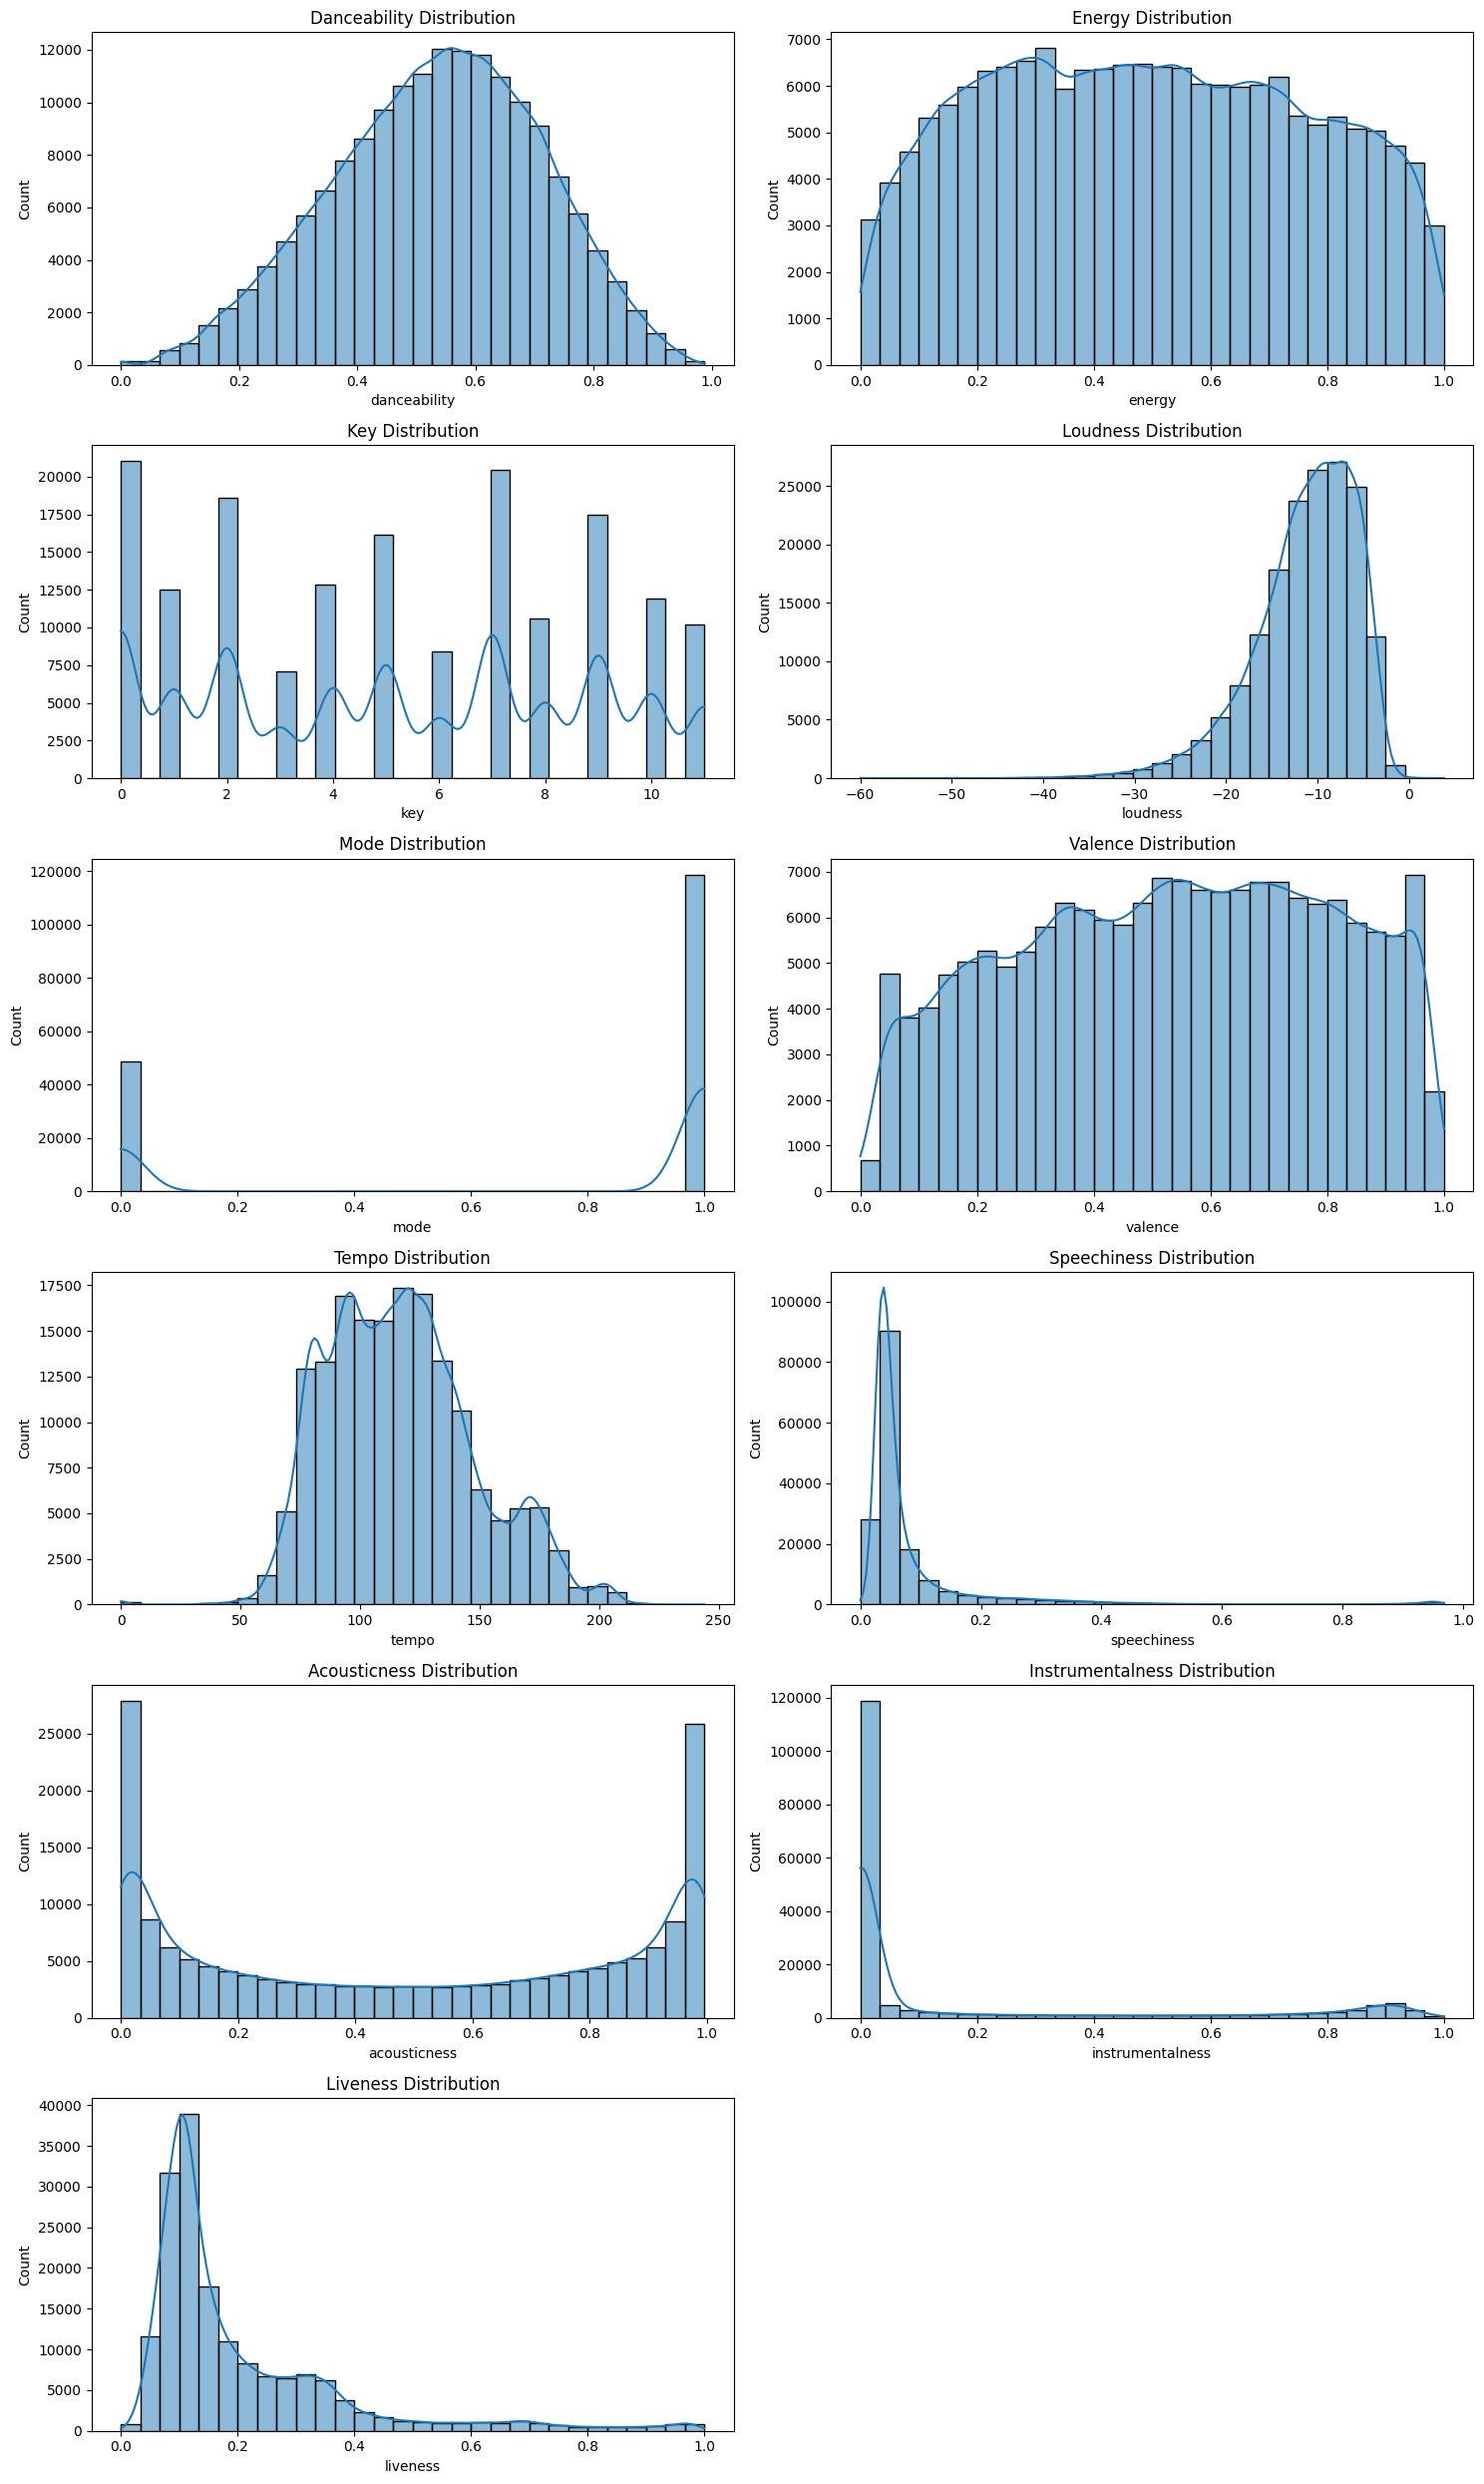

In [ ]:
all_audio_features = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'valence', 'tempo', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness'
]

Numerical_audio_features = [
    'danceability', 'energy', 'loudness',
    'valence', 'tempo', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness'
]

plt.figure(figsize=(15, 25))
for i, feature in enumerate(all_audio_features):
    plt.subplot(6, 2, i + 1)
    sns.histplot(data[feature].dropna(), bins=30, kde=True)
    plt.title(f'{feature.title()} Distribution')
plt.tight_layout()
plt.show()


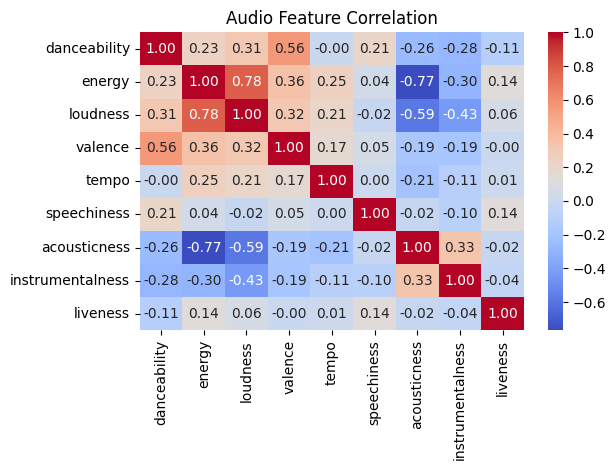

In [ ]:
sns.heatmap(data[Numerical_audio_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Audio Feature Correlation')
plt.tight_layout()
plt.show()


In [ ]:
print(data[Numerical_audio_features].var().sort_values())


speechiness           0.014424
danceability          0.030791
liveness              0.031221
valence               0.069433
energy                0.071210
instrumentalness      0.096087
acousticness          0.142135
loudness             31.684011
tempo               942.979031
dtype: float64


In [ ]:
# mode is intentionally excluded from similarity features —
# it is used as a hard filter in Stage 2 instead
audio_features = [
                  'energy',
                  'loudness',
                  #'valence',
                  #'instrumentalness',
                  #'danceability',
                  'acousticness']

data[audio_features] = data[audio_features].fillna(0)
# data['artist_genres'] = data['artist_genres'].fillna('')
data['artists'] = data['artists'].fillna('')

print('Features used for similarity:', audio_features)
print('Mode distribution (0=minor, 1=major):')
print(data['mode'].value_counts())


Features used for similarity: ['energy', 'loudness', 'acousticness']
Mode distribution (0=minor, 1=major):
mode
1    109202
0     44887
Name: count, dtype: int64


In [ ]:
# Drop duplicates based on the newly created 'combined_name'
data = data.drop_duplicates(subset=['combined_name']).reset_index(drop=True)
print(f'Shape after dropping combined_name duplicates: {data.shape}')

Shape after dropping combined_name duplicates: (154089, 14)


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197 (788.00 B)

 Trainable params: 197 (788.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2975 - val_loss: 0.0743
Epoch 2/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0563 - val_loss: 0.0517
Epoch 3/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0474 - val_loss: 0.0465
Epoch 4/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0439 - val_loss: 0.0434
Epoch 5/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0406 - val_loss: 0.0387
Epoch 6/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0351 - val_loss: 0.0344
Epoch 7/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0323 - val_loss: 0.0325
Epoch 8/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0311 - val_loss: 0.0313
Epoch 9/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0302 - val_loss: 0.0304
Epoch 10/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0296 - val_loss: 0.0298
Epoch 11/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0291 - val_loss: 0.0294
Epoch 12/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

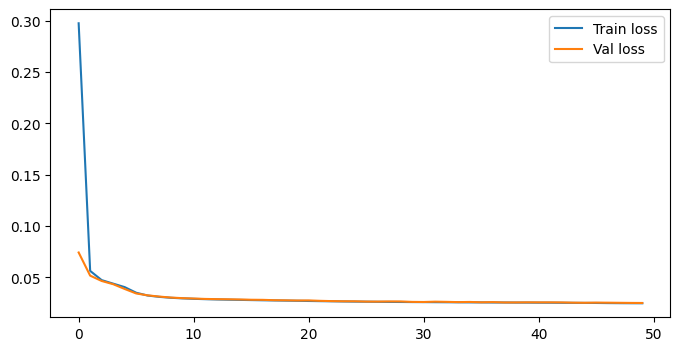

NearestNeighbors(algorithm='ball_tree', metric='euclidean', n_jobs=-1,
                 n_neighbors=500)

In [ ]:
# Preprocessing
scaler = StandardScaler()
audio_matrix = scaler.fit_transform(data[audio_features])
data = data.reset_index(drop=True)

X_train = audio_matrix.astype(np.float32)

# Autoencoder
input_dim = audio_matrix.shape[1]
...

autoencoder.summary()

# Train ONCE
history = autoencoder.fit(
...
)

# Plot losses
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.legend()
plt.show()

# Latent vectors
latent_matrix = encoder.predict(X_train, batch_size=512, verbose=0)

# KNN
knn_model = NearestNeighbors(
    n_neighbors=500,
    metric='euclidean',
    algorithm='ball_tree',
    n_jobs=-1
)

knn_model.fit(latent_matrix)

In [ ]:
def get_recommendations(combined_name_query, top_n=10):
    """
    Three-stage recommendation (Autoencoder + KNN version):
      Stage 1 : Exclude songs by the same artist
      Stage 2 : Exclude songs with a different mode
      Stage 3 : KNN in 16-dim autoencoder latent space

    similarity_score = 1 - (d / max_d)  →  1.0 = closest in latent space.

    Query format: 'Artist <> Track Title'
    """
...
    return recommendations


In [ ]:
recommended_songs = get_recommendations('ASIAN KUNG-FU GENERATION <> Re:Re:')
print(recommended_songs)


                                      combined_name  \
0          Rich Boy, Polow Da Don <> Throw Some D's   
1              The Rolling Stones <> Love Is Strong   
2                           Grouplove <> Lovely Cup   
3  Ed Helms, The Lorax Singers <> How Bad Can I Be?   
4               Thomas Rhett <> Get Me Some Of That   
5                               Earshot <> Get Away   
6     Streetlight Manifesto <> Point / Counterpoint   
7             Queen <> Don't Stop Me Now - 2011 Mix   
8                    Dave Matthews Band <> Spaceman   
9                           Lifehouse <> Falling In   

                           name                      artists  mode  \
0                Throw Some D's       Rich Boy, Polow Da Don     1   
1                Love Is Strong           The Rolling Stones     1   
2                    Lovely Cup                    Grouplove     1   
3             How Bad Can I Be?  Ed Helms, The Lorax Singers     1   
4           Get Me Some Of That             

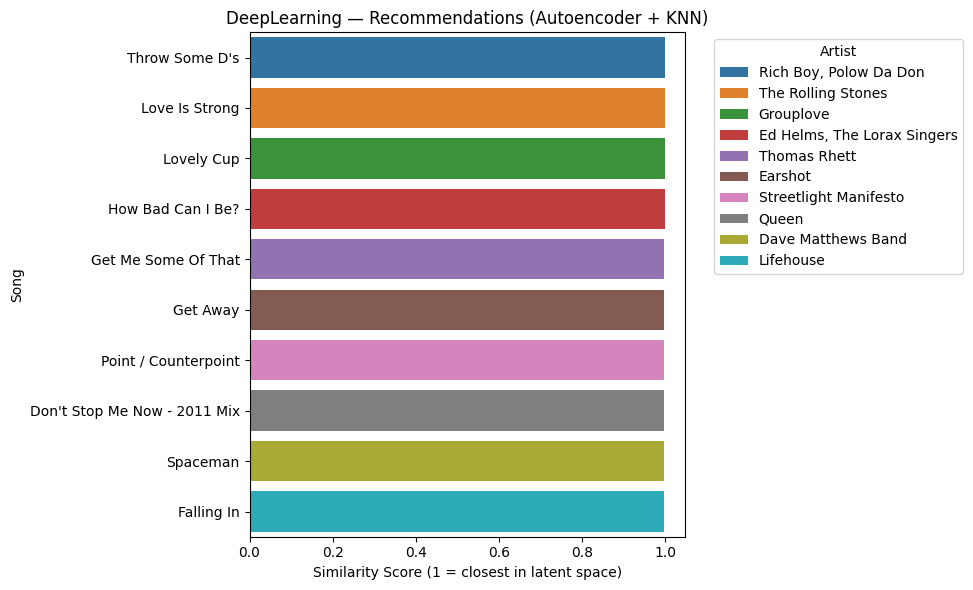

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=recommended_songs,
    y='name',
    x='similarity_score',
    hue='artists',
    dodge=False
)
plt.title('DeepLearning — Recommendations (Autoencoder + KNN)')
plt.xlabel('Similarity Score (1 = closest in latent space)')
plt.ylabel('Song')
plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Evaluation


Reconstruction error (MSE) statistics:
  Mean   : 0.024765
  Std    : 0.064588
  Median : 0.007303
  95th percentile : 0.104489


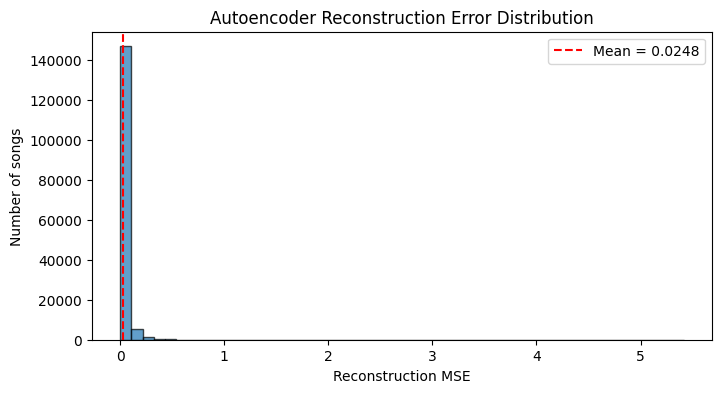

In [ ]:
# After training the autoencoder (autoencoder fitted on X_scaled)
# Get reconstructions for the entire dataset
X_reconstructed = autoencoder.predict(X_train, verbose=0)

# Compute reconstruction error per sample (MSE)
reconstruction_errors = np.mean((X_train - X_reconstructed) ** 2, axis=1)

print("Reconstruction error (MSE) statistics:")
print(f"  Mean   : {np.mean(reconstruction_errors):.6f}")
print(f"  Std    : {np.std(reconstruction_errors):.6f}")
print(f"  Median : {np.median(reconstruction_errors):.6f}")
print(f"  95th percentile : {np.percentile(reconstruction_errors, 95):.6f}")

# Optional: plot histogram of reconstruction errors
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(reconstruction_errors, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Reconstruction MSE')
plt.ylabel('Number of songs')
plt.title('Autoencoder Reconstruction Error Distribution')
plt.axvline(np.mean(reconstruction_errors), color='red', linestyle='--', label=f'Mean = {np.mean(reconstruction_errors):.4f}')
plt.legend()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X_train)
print(pca.explained_variance_ratio_)

[0.80708605 0.13898374]
